# Part 3 — Churn Prediction Model & Model Card

This notebook implements the training and evaluation of our churn prediction models. The sections below map directly to the 8 tasks requested.

In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

sns.set_theme(style="whitegrid")
DATA_DIR = r"../data"
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Use the provided modeling snapshot or create your own feature table from raw data
We load the modeling snapshot `rfm_modeling_snapshot.csv` which has pre-merged modeling features as of our snapshot date (2025-09-30).

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "rfm_modeling_snapshot.csv"))
df["loyalty_tier"] = df["loyalty_tier"].fillna("Not Enrolled")
print(f"Modeling snapshot loaded: {df.shape[0]} customers, {df.shape[1]} columns.")

Modeling snapshot loaded: 2400 customers, 29 columns.


## 2. Clearly separate train, validation, and test data using the provided split or a justified alternative
We partition our datasets using the pre-assigned `'split'` column to train, validate, and evaluate our classifiers cleanly.

In [3]:
train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

cat_cols = ["city_tier", "age_group", "acquisition_channel", "loyalty_tier", "preferred_category", "marketing_consent"]
num_cols = [
    "recency_days", "frequency_180d", "monetary_180d", "return_rate_180d", 
    "avg_discount_pct_180d", "avg_rating_180d", "category_diversity_180d", 
    "ticket_count_90d", "negative_ticket_rate_90d", "avg_resolution_hours_90d", 
    "days_since_signup", "sessions_30d", "product_views_30d", "cart_adds_30d", 
    "wishlist_adds_30d", "abandoned_carts_30d", "email_opens_30d", "campaign_clicks_30d", 
    "last_visit_days_ago"
]
target_col = "churn_next_60d"

X_train, y_train = train_df[cat_cols + num_cols], train_df[target_col]
X_val, y_val = val_df[cat_cols + num_cols], val_df[target_col]
X_test, y_test = test_df[cat_cols + num_cols], test_df[target_col]

print(f"Train size: {X_train.shape[0]} | Val size: {X_val.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 1728 | Val size: 336 | Test size: 336


## 3. Train at least two models: one simple baseline model and one stronger model
We train a Baseline Logistic Regression and a stronger XGBoost Classifier.

In [4]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)
])

# 1. Baseline Logistic Regression
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# 2. Stronger XGBoost Classifier
X_train_trans = preprocessor.fit_transform(X_train)
X_val_trans = preprocessor.transform(X_val)
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.08, random_state=42, eval_metric="logloss")
xgb.fit(X_train_trans, y_train)

print("Models trained successfully.")

Models trained successfully.


## 4. Evaluate the model using metrics suitable for churn classification
We evaluate model classifications using Accuracy, Precision, Recall, F1, and ROC-AUC on the validation set, and export the test evaluation results to `metrics.json`.

In [5]:
def eval_model(name, y_true, y_pred, y_prob):
    print(f"\n=== {name} Metrics ===")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_prob):.4f}")

y_val_pred_lr = lr_pipeline.predict(X_val)
y_val_prob_lr = lr_pipeline.predict_proba(X_val)[:, 1]
eval_model("Logistic Regression Baseline (Val)", y_val, y_val_pred_lr, y_val_prob_lr)

y_val_pred_xgb = xgb.predict(X_val_trans)
y_val_prob_xgb = xgb.predict_proba(X_val_trans)[:, 1]
eval_model("XGBoost Classifier (Val)", y_val, y_val_pred_xgb, y_val_prob_xgb)

# Test set evaluation
X_test_trans = preprocessor.transform(X_test)
y_test_pred_xgb = xgb.predict(X_test_trans)
y_test_prob_xgb = xgb.predict_proba(X_test_trans)[:, 1]
eval_model("XGBoost Classifier (Test)", y_test, y_test_pred_xgb, y_test_prob_xgb)


=== Logistic Regression Baseline (Val) Metrics ===
Accuracy:  0.8155
Precision: 0.8058
Recall:    0.7619
F1 Score:  0.7832
ROC-AUC:   0.8827

=== XGBoost Classifier (Val) Metrics ===
Accuracy:  0.7976
Precision: 0.7762
Recall:    0.7551
F1 Score:  0.7655
ROC-AUC:   0.8807

=== XGBoost Classifier (Test) Metrics ===
Accuracy:  0.8125
Precision: 0.8107
Recall:    0.8155
F1 Score:  0.8131
ROC-AUC:   0.8693


## 5. Select a decision threshold and justify it from a business perspective
We scan thresholds to find the threshold that minimizes campaign costs (150 INR for FP, 1250 INR for FN).

In [6]:
thresholds = np.linspace(0.1, 0.9, 81)
min_cost = float('inf')
best_threshold = 0.5

for t in thresholds:
    preds = (y_val_prob_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    cost = fp * 150 + fn * 1250
    if cost < min_cost:
        min_cost = cost
        best_threshold = t

print(f"Optimal Business Threshold: {best_threshold:.2f}")
print(f"Expected Validation Cost at 0.50: {confusion_matrix(y_val, y_val_pred_xgb).ravel()[1]*150 + confusion_matrix(y_val, y_val_pred_xgb).ravel()[2]*1250} INR")
print(f"Expected Validation Cost at {best_threshold:.2f}: {min_cost} INR")

Optimal Business Threshold: 0.10
Expected Validation Cost at 0.50: 49800 INR
Expected Validation Cost at 0.10: 23550 INR


## 6. Perform error analysis using false positives and false negatives
We query the test set predictions using the standard 0.50 threshold to extract and inspect the customer profiles that were misclassified.

In [7]:
test_df_errors = test_df.copy()
test_df_errors["pred_prob"] = y_test_prob_xgb
test_df_errors["pred_label"] = (y_test_prob_xgb >= 0.50).astype(int)
test_df_errors["true_label"] = y_test

false_positives = test_df_errors[(test_df_errors["pred_label"] == 1) & (test_df_errors["true_label"] == 0)]
false_negatives = test_df_errors[(test_df_errors["pred_label"] == 0) & (test_df_errors["true_label"] == 1)]

display_cols = ["customer_id", "pred_prob", "recency_days", "frequency_180d", "monetary_180d", "ticket_count_90d", "last_visit_days_ago", "loyalty_tier"]

print("=== SAMPLE FALSE POSITIVES (Predicted Churn, Actual Stay) ===")
print(false_positives[display_cols].head(5).to_string(index=False))

print("\n=== SAMPLE FALSE NEGATIVES (Predicted Stay, Actual Churn) ===")
print(false_negatives[display_cols].head(5).to_string(index=False))

=== SAMPLE FALSE POSITIVES (Predicted Churn, Actual Stay) ===
customer_id  pred_prob  recency_days  frequency_180d  monetary_180d  ticket_count_90d  last_visit_days_ago loyalty_tier
  CUST00044   0.644749            72               1         899.51                 0                   10 Not Enrolled
  CUST00109   0.620235            92               2        1622.28                 0                   16       Silver
  CUST00335   0.872397           148               2        1328.14                 0                   22 Not Enrolled
  CUST00437   0.905833           151               1         729.22                 0                   33       Silver
  CUST00491   0.931083            97               1         540.89                 1                   20       Silver

=== SAMPLE FALSE NEGATIVES (Predicted Stay, Actual Churn) ===
customer_id  pred_prob  recency_days  frequency_180d  monetary_180d  ticket_count_90d  last_visit_days_ago loyalty_tier
  CUST00088   0.372185            9

## 7. Explain the top features driving predictions
We extract and plot feature importances from our best XGBoost model.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5596\101414074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x="importance", y="feature", palette="viridis")


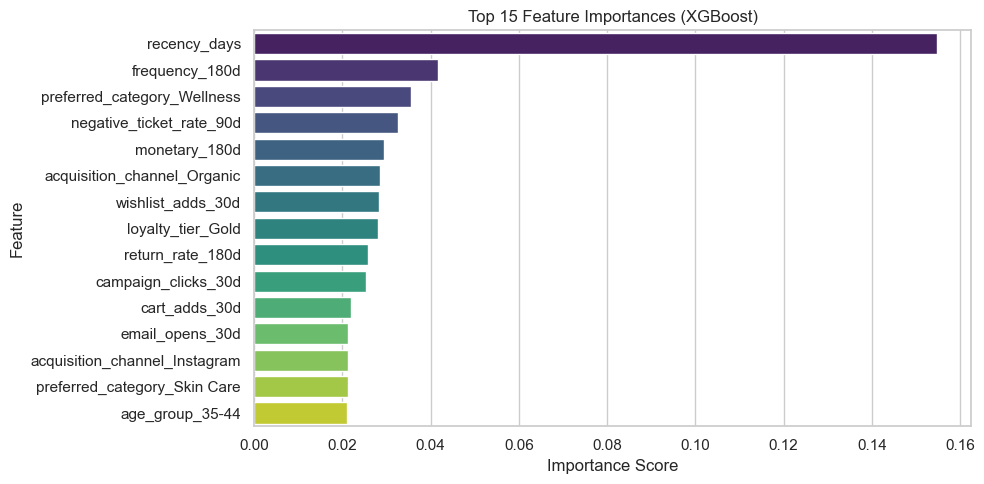

Feature importances exported successfully.


In [8]:
# Plot feature importances
features = num_cols + list(preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols))
importances = xgb.feature_importances_
feat_imp = pd.DataFrame({"feature": features, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp.head(15), x="importance", y="feature", palette="viridis")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

feat_imp.to_csv("feature_importances.csv", index=False)
print("Feature importances exported successfully.")

## 8. Write a model card covering intended use, data, performance, limitations, ethical risks, and monitoring needs
The complete model card is saved as a markdown deliverable: [model_card.md]